# Kentsel İyileştirme Projelerinde Bütçe Optimizasyonu: Veri Görselleştirme

Bu notebook, sunum taslağındaki ilgili slaytlara yönelik veri görselleştirmelerini içermektedir.

Kullanılan kütüphaneler:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re # Regular expressions for column parsing

# Grafik stili ve renk paleti ayarları
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (12, 7) # Varsayılan figür boyutu
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

## Veri Dosyalarının Yüklenmesi

In [3]:
try:
    df_districts_data = pd.read_csv("birlesik_ilce_verisi.csv")
    print("--- birlesik_ilce_verisi.csv Yüklendi ---")
    df_districts_data.info()
except FileNotFoundError:
    print("HATA: 'birlesik_ilce_verisi.csv' bulunamadı.")
    df_districts_data = None

try:
    df_results_raw = pd.read_csv("new_optimum_yesil_alan_sonuclari_SCENARIOS.csv")
    print("\n--- new_optimum_yesil_alan_sonuclari_SCENARIOS.csv Yüklendi ---")
    df_results_raw.info()
except FileNotFoundError:
    print("HATA: 'new_optimum_yesil_alan_sonuclari_SCENARIOS.csv' bulunamadı.")
    df_results_raw = None

--- birlesik_ilce_verisi.csv Yüklendi ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ILCE                   39 non-null     object 
 1   alan_metrekare         39 non-null     float64
 2   Nufus                  39 non-null     float64
 3   Minibus_Durak_Sayisi   39 non-null     int64  
 4   Rayli_Istasyon_Sayisi  39 non-null     int64  
 5   Taksi_Durak_Sayisi     39 non-null     int64  
 6   Ortalama_AQI           39 non-null     float64
dtypes: float64(3), int64(3), object(1)
memory usage: 2.3+ KB

--- new_optimum_yesil_alan_sonuclari_SCENARIOS.csv Yüklendi ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 51 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   ILCE 

--- 
## Slayt 3: Veri Seti (`birlesik_ilce_verisi.csv`) ve Amaç Fonksiyonu

Bu bölümde, optimizasyon probleminde kullanılan temel ilçe verilerinin bazı özellikleri görselleştirilecektir.

### 3.1. Veri Setine Genel Bakış

In [4]:
if df_districts_data is not None:
    print("İlk 5 Satır (birlesik_ilce_verisi.csv):")
    display(df_districts_data.head())
    print("\nİstatistiksel Özet:")
    display(df_districts_data.describe().transpose())
else:
    print("'birlesik_ilce_verisi.csv' yüklenemediği için bu bölüm atlanıyor.")

İlk 5 Satır (birlesik_ilce_verisi.csv):


,ILCE,alan_metrekare,Nufus,Minibus_Durak_Sayisi,Rayli_Istasyon_Sayisi,Taksi_Durak_Sayisi,Ortalama_AQI
0,ADALAR,51158.829550,16979.0,0,0,0,21.872800
1,ARNAVUTKÖY,64545.192126,344868.0,204,5,2,29.735716
2,ATAŞEHİR,652554.349856,414866.0,293,8,29,29.787501
3,AVCILAR,758438.617676,440934.0,153,2,12,29.202595
4,BAHÇELİEVLER,172658.041124,560086.0,240,9,14,36.609391



İstatistiksel Özet:


,count,mean,std,min,25%,50%,75%,max
alan_metrekare,39.0,1.404675e+06,1.356832e+06,29380.789242,552648.424089,860383.266437,1.916942e+06,7.189931e+06
Nufus,39.0,4.026052e+05,2.050897e+05,16979.000000,266567.000000,414866.000000,5.075290e+05,9.883690e+05
Minibus_Durak_Sayisi,39.0,2.032051e+02,9.857142e+01,0.000000,143.500000,204.000000,2.750000e+02,3.960000e+02
Rayli_Istasyon_Sayisi,39.0,8.641026e+00,7.747622e+00,0.000000,2.500000,8.000000,1.050000e+01,2.700000e+01
Taksi_Durak_Sayisi,39.0,1.571795e+01,1.391128e+01,0.000000,7.000000,12.000000,1.950000e+01,6.200000e+01
Ortalama_AQI,39.0,3.588137e+01,8.208693e+00,21.872800,29.735716,36.609391,3.946438e+01,6.546189e+01


### 3.2. Temel Metriklerin Dağılımları

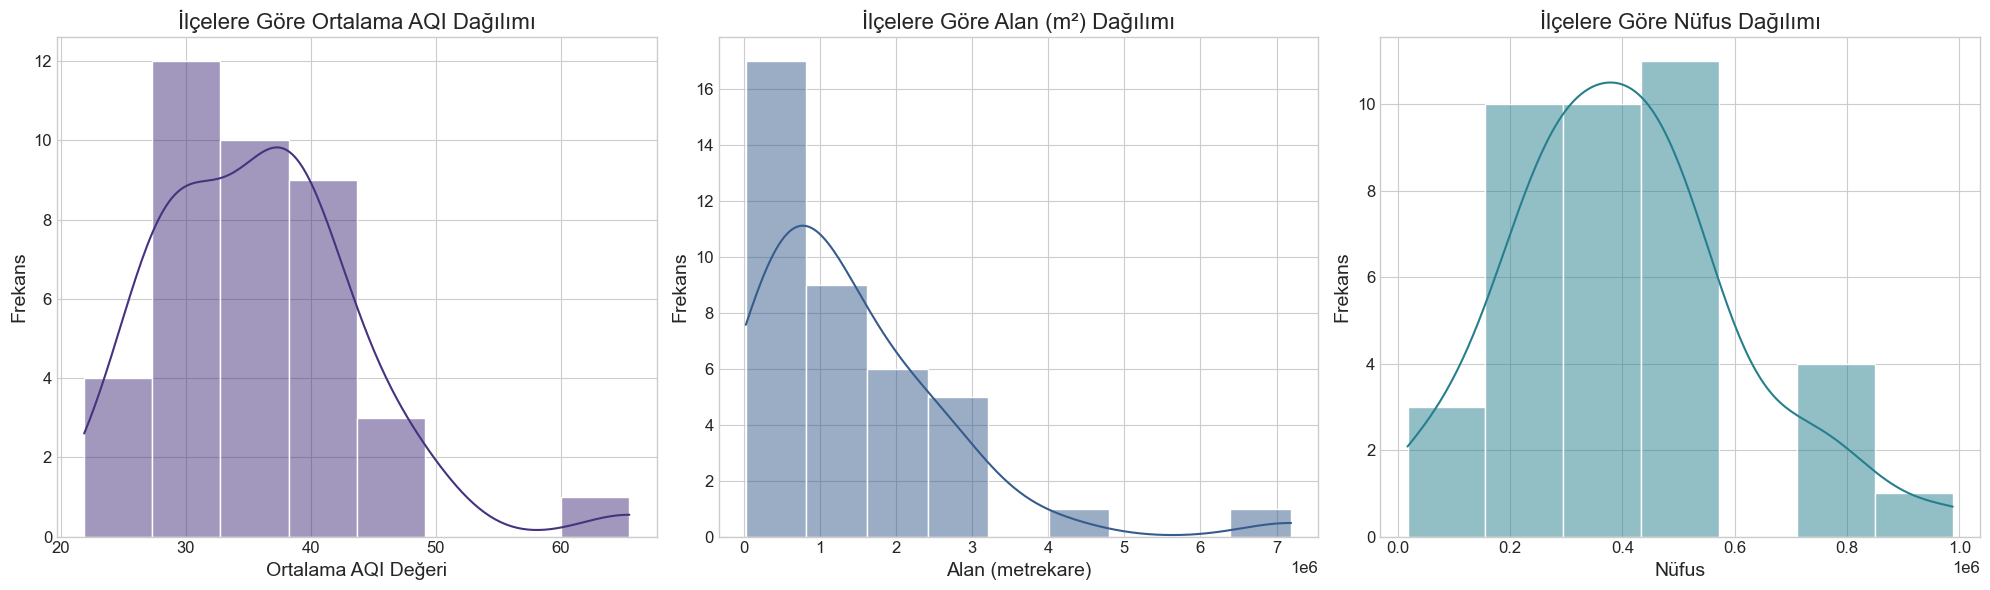

In [5]:
if df_districts_data is not None:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # Ortalama AQI Dağılımı
    if 'Ortalama_AQI' in df_districts_data.columns:
        sns.histplot(df_districts_data['Ortalama_AQI'], kde=True, ax=axes[0], color=sns.color_palette("viridis")[0])
        axes[0].set_title('İlçelere Göre Ortalama AQI Dağılımı')
        axes[0].set_xlabel('Ortalama AQI Değeri')
        axes[0].set_ylabel('Frekans')
    else:
        axes[0].text(0.5, 0.5, 'Ortalama_AQI sütunu bulunamadı.', ha='center', va='center')
        axes[0].set_title('Ortalama AQI Dağılımı')

    # Alan (metrekare) Dağılımı
    if 'alan_metrekare' in df_districts_data.columns:
        sns.histplot(df_districts_data['alan_metrekare'], kde=True, ax=axes[1], color=sns.color_palette("viridis")[1])
        axes[1].set_title('İlçelere Göre Alan (m²) Dağılımı')
        axes[1].set_xlabel('Alan (metrekare)')
        axes[1].set_ylabel('Frekans')
        axes[1].ticklabel_format(style='sci', axis='x', scilimits=(0,0)) # Büyük sayılar için bilimsel gösterim
    else:
        axes[1].text(0.5, 0.5, 'alan_metrekare sütunu bulunamadı.', ha='center', va='center')
        axes[1].set_title('Alan (m²) Dağılımı')
        
    # Nüfus Dağılımı
    if 'Nufus' in df_districts_data.columns:
        sns.histplot(df_districts_data['Nufus'], kde=True, ax=axes[2], color=sns.color_palette("viridis")[2])
        axes[2].set_title('İlçelere Göre Nüfus Dağılımı')
        axes[2].set_xlabel('Nüfus')
        axes[2].set_ylabel('Frekans')
        axes[2].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    else:
        axes[2].text(0.5, 0.5, 'Nufus sütunu bulunamadı.', ha='center', va='center')
        axes[2].set_title('Nüfus Dağılımı')
        
    plt.tight_layout()
    plt.show()
else:
    print("'birlesik_ilce_verisi.csv' yüklenemediği için bu bölüm atlanıyor.")

### 3.3. Ulaşım Metrikleri (En Kalabalık 10 İlçe)

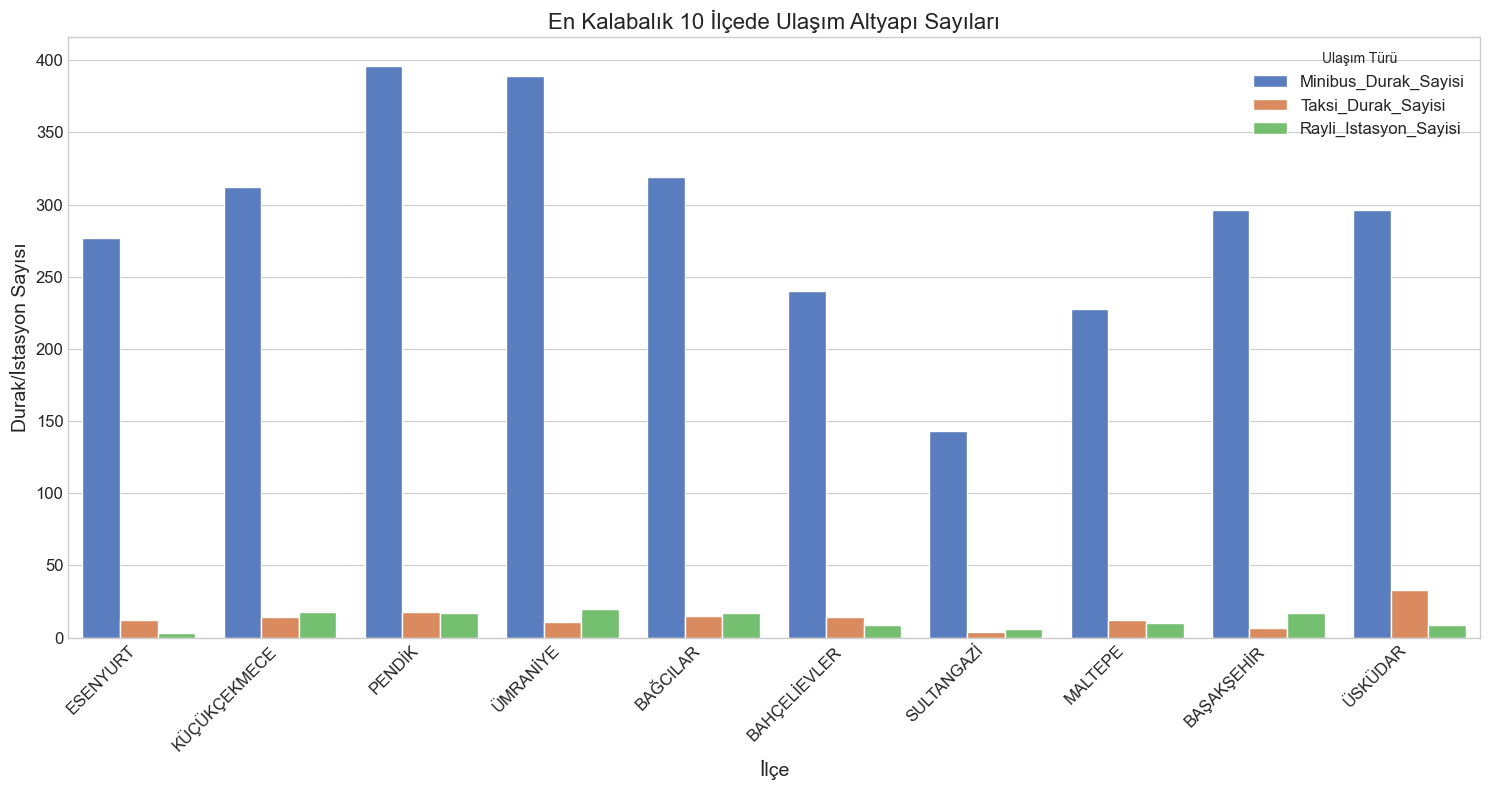

In [6]:
if df_districts_data is not None and 'Nufus' in df_districts_data.columns:
    top_n = 10
    df_top_districts = df_districts_data.nlargest(top_n, 'Nufus')
    
    df_transport = df_top_districts[['ILCE', 'Minibus_Durak_Sayisi', 'Taksi_Durak_Sayisi', 'Rayli_Istasyon_Sayisi']]
    df_transport_melted = df_transport.melt(id_vars='ILCE', var_name='Ulaşım Türü', value_name='Sayı')
    
    plt.figure(figsize=(15, 8))
    sns.barplot(data=df_transport_melted, x='ILCE', y='Sayı', hue='Ulaşım Türü', palette='muted')
    plt.title(f'En Kalabalık {top_n} İlçede Ulaşım Altyapı Sayıları')
    plt.xlabel('İlçe')
    plt.ylabel('Durak/İstasyon Sayısı')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Ulaşım Türü')
    plt.tight_layout()
    plt.show()
elif df_districts_data is None:
    print("'birlesik_ilce_verisi.csv' yüklenemediği için bu bölüm atlanıyor.")
else:
    print("'Nufus' sütunu 'birlesik_ilce_verisi.csv' içinde bulunamadı.")

--- 
## Slayt 6: Sonuçlar ve Tartışma (`new_optimum_yesil_alan_sonuclari_SCENARIOS.csv`)

Bu bölümde, optimizasyon algoritmalarının (GA ve PSO) farklı senaryolar altında elde ettiği sonuçlar görselleştirilecektir. `new_optimum_yesil_alan_sonuclari_SCENARIOS.csv` dosyası, her bir ilçe için senaryo ve algoritmaya göre "Yeni Yapılacak Yeşil Alan" ve "Toplam Yeşil Alan" miktarlarını içermektedir. **Not:** Bu dosyada doğrudan Z (amaç fonksiyonu) değerleri veya bütçe ($x_i$) değerleri bulunmamaktadır. Bu nedenle, performans metriği olarak "Toplam Yeni Yapılacak Yeşil Alan" kullanılacaktır.

### 6.1. Sonuç Verilerini Hazırlama ve Dönüştürme

Sonuç CSV dosyasındaki geniş formatlı veriyi, analiz ve görselleştirme için daha uygun olan uzun formata dönüştüreceğiz.

In [7]:
def parse_column_name(col_name):
    # Örnek: Yeni_Yapilacak_Yesil_Alan_GA_W1_0.7_W2_0.3
    # Örnek: Toplam_Yesil_Alan_PSO_W1_1.0_W2_0.0
    
    pattern = re.compile(r"(Yeni_Yapilacak_Yesil_Alan|Toplam_Yesil_Alan)_(GA|PSO)_W1_(\d\.\d)_W2_(\d\.\d)")
    match = pattern.match(col_name)
    if match:
        metric_type = match.group(1)
        algorithm = match.group(2)
        w1 = float(match.group(3))
        w2 = float(match.group(4))
        return metric_type, algorithm, w1, w2
    return None, None, None, None

if df_results_raw is not None:
    id_vars = ['ILCE', 'alan_metrekare', 'Nufus', 'Minibus_Durak_Sayisi', 
                 'Rayli_Istasyon_Sayisi', 'Taksi_Durak_Sayisi', 'Ortalama_AQI']
    value_vars = [col for col in df_results_raw.columns if col not in id_vars]
    
    df_results_long = pd.melt(df_results_raw, id_vars=id_vars, value_vars=value_vars, 
                              var_name='Scenario_Raw', value_name='Value')
    
    # Ayrıştırılmış sütunları ekleyelim
    parsed_cols = df_results_long['Scenario_Raw'].apply(lambda x: pd.Series(parse_column_name(x)))
    parsed_cols.columns = ['Metric_Type', 'Algorithm', 'W1', 'W2']
    
    df_results_long = pd.concat([df_results_long, parsed_cols], axis=1)
    
    # 'Value' sütununu Metric_Type'a göre ayıralım
    df_results_final = df_results_long.pivot_table(
        index=['ILCE', 'alan_metrekare', 'Nufus', 'Minibus_Durak_Sayisi', 
               'Rayli_Istasyon_Sayisi', 'Taksi_Durak_Sayisi', 'Ortalama_AQI', 
               'Algorithm', 'W1', 'W2'], 
        columns='Metric_Type', 
        values='Value'
    ).reset_index()
    
    # Gereksiz sütunları ve NaN içeren satırları temizleyelim (parsing hatası sonucu oluşabilir)
    df_results_final.dropna(subset=['Algorithm', 'W1', 'W2'], inplace=True)
    
    print("Dönüştürülmüş Sonuç Verisi (İlk 5 Satır):")
    display(df_results_final.head())
    print("\nVeri Tipleri:")
    df_results_final.info()
else:
    print("'new_optimum_yesil_alan_sonuclari_SCENARIOS.csv' yüklenemediği için bu bölüm atlanıyor.")
    df_results_final = None

Dönüştürülmüş Sonuç Verisi (İlk 5 Satır):


Metric_Type,ILCE,alan_metrekare,Nufus,Minibus_Durak_Sayisi,Rayli_Istasyon_Sayisi,Taksi_Durak_Sayisi,Ortalama_AQI,Algorithm,W1,W2,Toplam_Yesil_Alan,Yeni_Yapilacak_Yesil_Alan
0,ADALAR,51158.82955,16979.0,0,0,0,21.8728,GA,0.0,1.0,54665.600555,3506.771005
1,ADALAR,51158.82955,16979.0,0,0,0,21.8728,GA,0.1,0.9,58827.852530,7669.022980
2,ADALAR,51158.82955,16979.0,0,0,0,21.8728,GA,0.2,0.8,54290.307707,3131.478157
3,ADALAR,51158.82955,16979.0,0,0,0,21.8728,GA,0.3,0.7,59932.998838,8774.169288
4,ADALAR,51158.82955,16979.0,0,0,0,21.8728,GA,0.4,0.6,56719.548103,5560.718553



Veri Tipleri:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ILCE                       858 non-null    object 
 1   alan_metrekare             858 non-null    float64
 2   Nufus                      858 non-null    float64
 3   Minibus_Durak_Sayisi       858 non-null    int64  
 4   Rayli_Istasyon_Sayisi      858 non-null    int64  
 5   Taksi_Durak_Sayisi         858 non-null    int64  
 6   Ortalama_AQI               858 non-null    float64
 7   Algorithm                  858 non-null    object 
 8   W1                         858 non-null    float64
 9   W2                         858 non-null    float64
 10  Toplam_Yesil_Alan          858 non-null    float64
 11  Yeni_Yapilacak_Yesil_Alan  858 non-null    float64
dtypes: float64(7), int64(3), object(2)
memory usage: 80.6+ KB


### 6.2. Genel Performans (Toplam Yeni Yeşil Alan Miktarı Üzerinden)

Farklı senaryolar ve algoritmalar için tüm ilçelerde oluşturulan toplam yeni yeşil alan miktarını karşılaştıracağız.

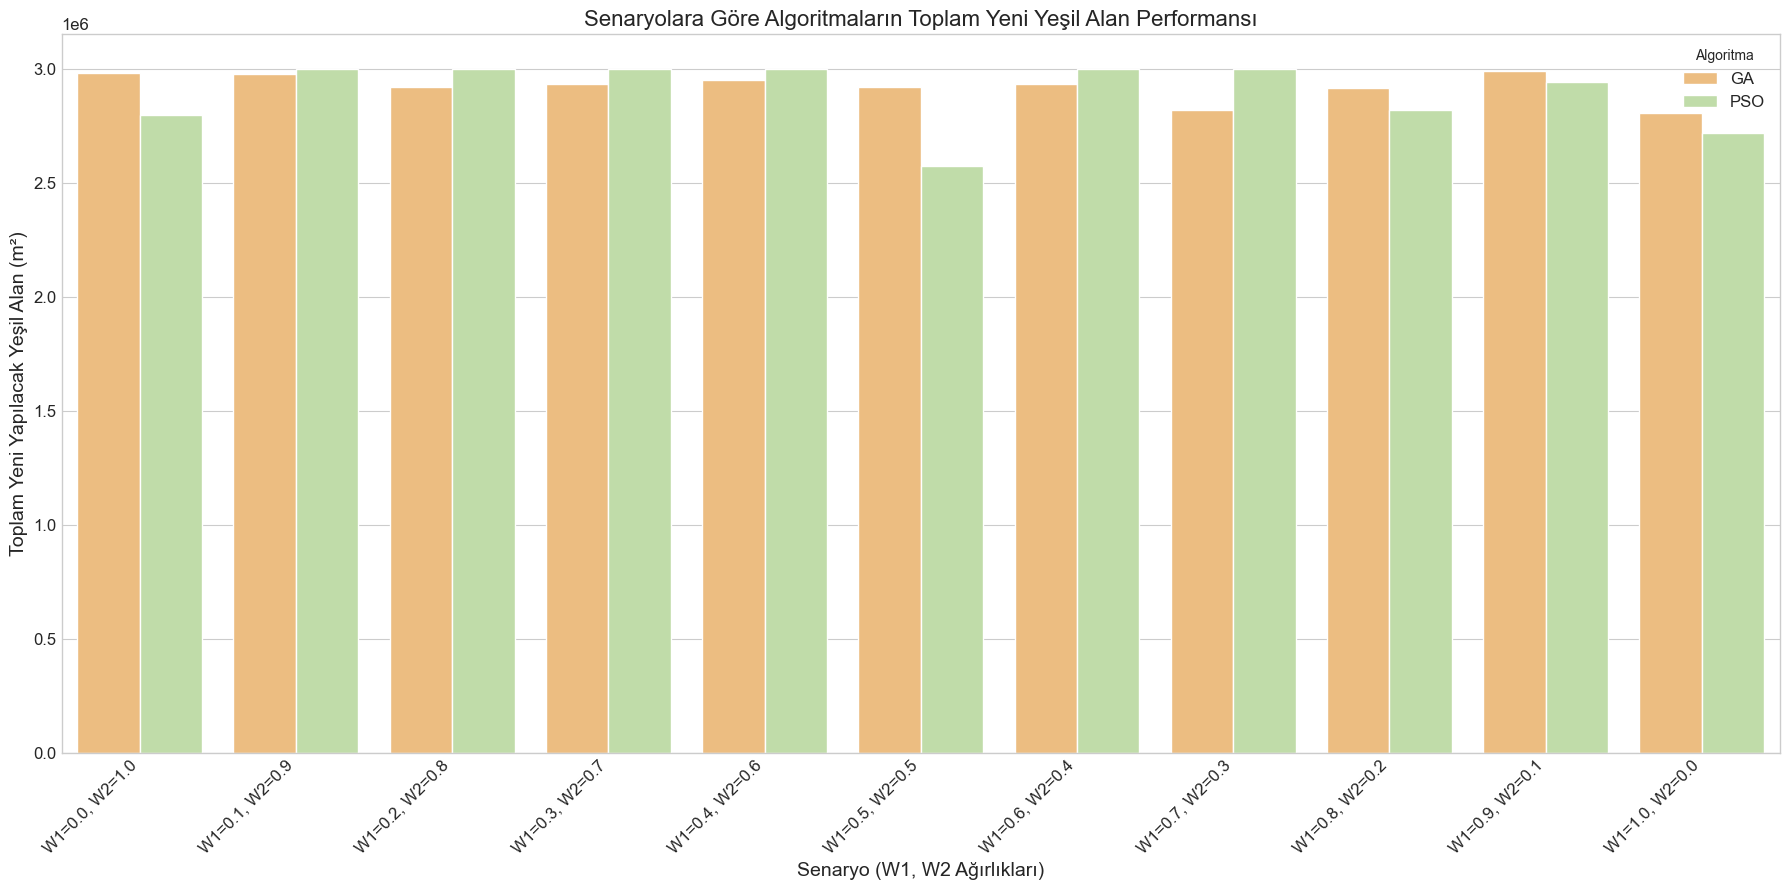

In [8]:
if df_results_final is not None and 'Yeni_Yapilacak_Yesil_Alan' in df_results_final.columns:
    # Her senaryo ve algoritma için toplam yeni yeşil alanı hesapla
    df_performance = df_results_final.groupby(['W1', 'W2', 'Algorithm'])['Yeni_Yapilacak_Yesil_Alan'].sum().reset_index()
    df_performance['Scenario'] = 'W1=' + df_performance['W1'].astype(str) + ', W2=' + df_performance['W2'].astype(str)
    
    plt.figure(figsize=(18, 9))
    sns.barplot(data=df_performance, x='Scenario', y='Yeni_Yapilacak_Yesil_Alan', hue='Algorithm', palette='Spectral')
    plt.title('Senaryolara Göre Algoritmaların Toplam Yeni Yeşil Alan Performansı')
    plt.xlabel('Senaryo (W1, W2 Ağırlıkları)')
    plt.ylabel('Toplam Yeni Yapılacak Yeşil Alan (m²)')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Algoritma')
    plt.tight_layout()
    plt.show()
elif df_results_final is None:
    print("Sonuç verileri işlenemediği için bu bölüm atlanıyor.")
else:
    print("'Yeni_Yapilacak_Yesil_Alan' sütunu işlenmiş sonuçlarda bulunamadı.")

### 6.3. Örnek Senaryo Analizi: Yeni Yeşil Alan Dağılımı (W1=0.5, W2=0.5)

Dengeli ağırlık senaryosu (W1=0.5, W2=0.5) için GA ve PSO'nun ilçelere göre oluşturduğu yeni yeşil alan miktarlarını inceleyelim. En çok yeşil alan oluşturulan ilk 10 ilçeyi göstereceğiz.

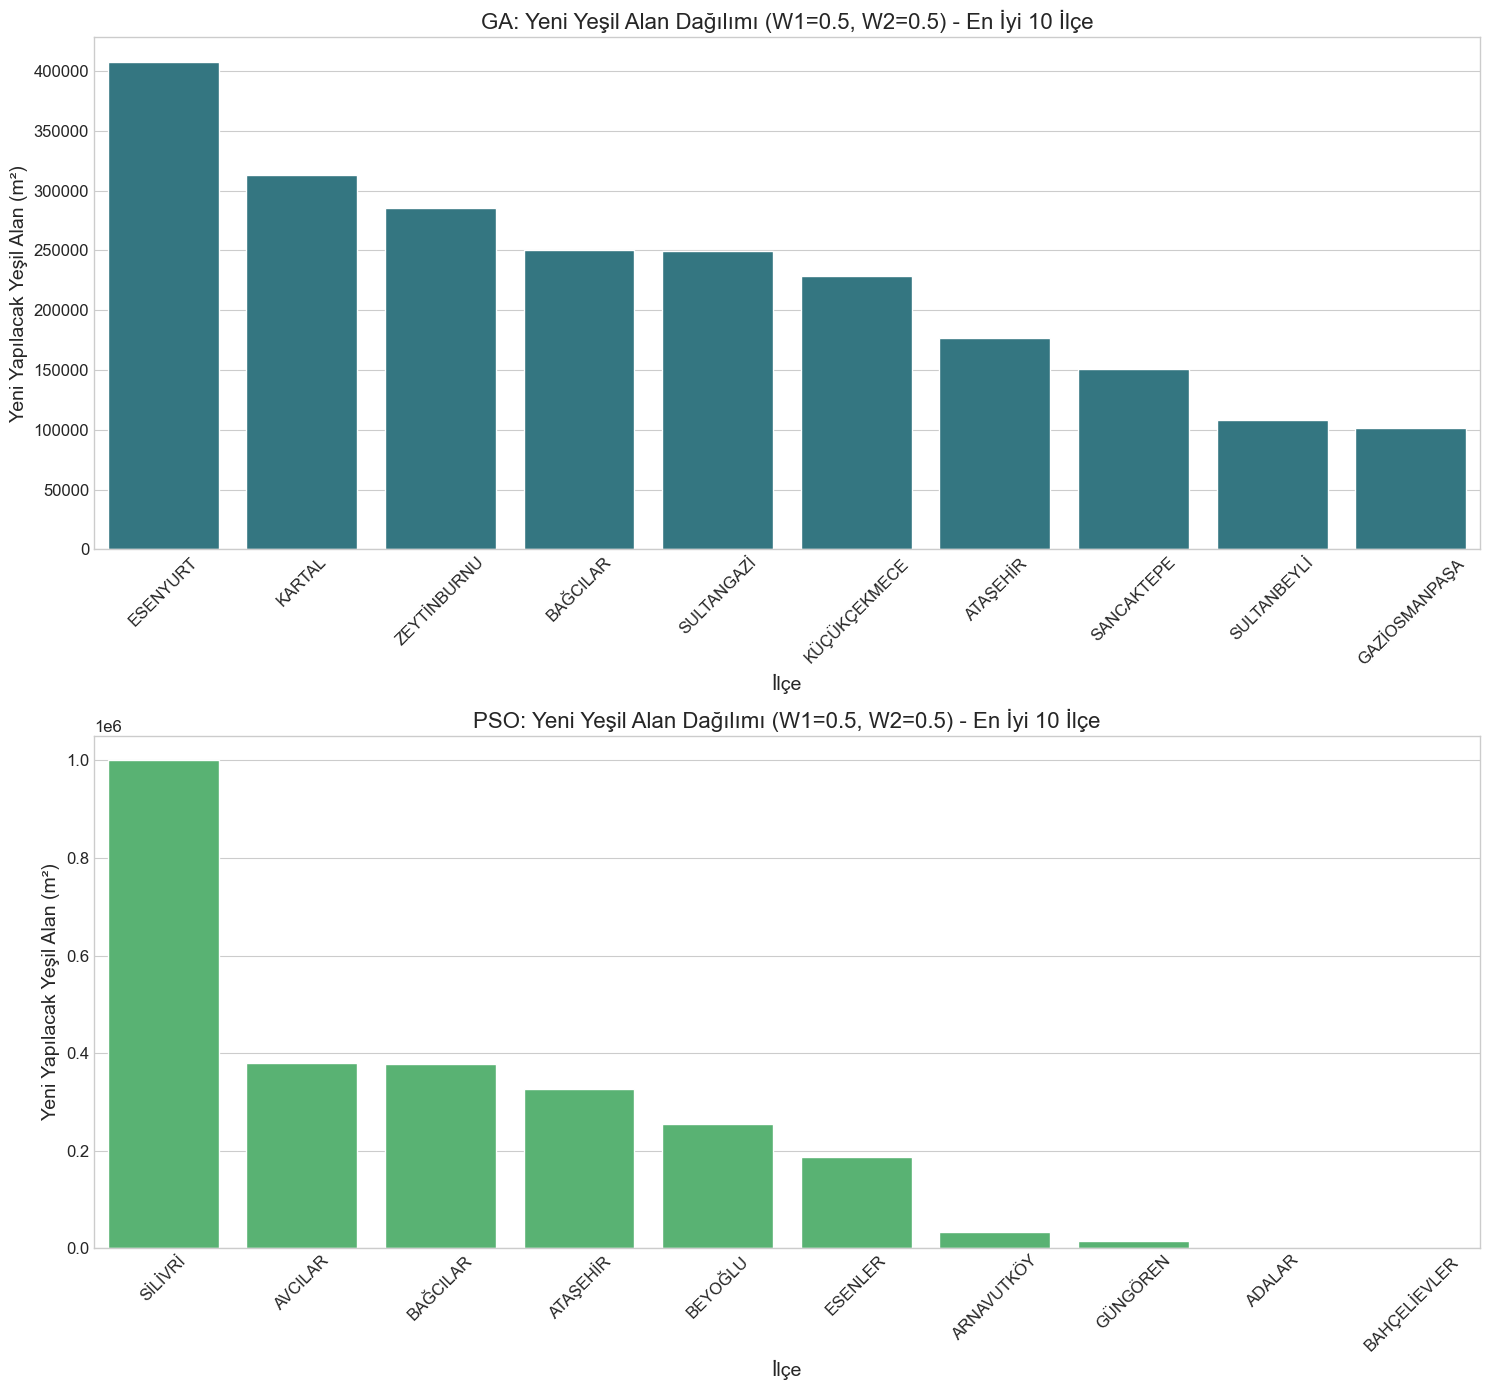

In [9]:
if df_results_final is not None and 'Yeni_Yapilacak_Yesil_Alan' in df_results_final.columns:
    target_w1, target_w2 = 0.5, 0.5
    df_scenario_sample = df_results_final[
        (df_results_final['W1'] == target_w1) & 
        (df_results_final['W2'] == target_w2)
    ]
    
    if not df_scenario_sample.empty:
        fig, axes = plt.subplots(2, 1, figsize=(15, 14), sharex=False)
        top_n_districts = 10
        
        # GA için
        df_ga_sample = df_scenario_sample[df_scenario_sample['Algorithm'] == 'GA'].nlargest(top_n_districts, 'Yeni_Yapilacak_Yesil_Alan')
        sns.barplot(data=df_ga_sample, x='ILCE', y='Yeni_Yapilacak_Yesil_Alan', ax=axes[0], color=sns.color_palette("viridis")[2])
        axes[0].set_title(f'GA: Yeni Yeşil Alan Dağılımı (W1={target_w1}, W2={target_w2}) - En İyi {top_n_districts} İlçe')
        axes[0].set_xlabel('İlçe')
        axes[0].set_ylabel('Yeni Yapılacak Yeşil Alan (m²)')
        axes[0].tick_params(axis='x', rotation=45)
        
        # PSO için
        df_pso_sample = df_scenario_sample[df_scenario_sample['Algorithm'] == 'PSO'].nlargest(top_n_districts, 'Yeni_Yapilacak_Yesil_Alan')
        sns.barplot(data=df_pso_sample, x='ILCE', y='Yeni_Yapilacak_Yesil_Alan', ax=axes[1], color=sns.color_palette("viridis")[4])
        axes[1].set_title(f'PSO: Yeni Yeşil Alan Dağılımı (W1={target_w1}, W2={target_w2}) - En İyi {top_n_districts} İlçe')
        axes[1].set_xlabel('İlçe')
        axes[1].set_ylabel('Yeni Yapılacak Yeşil Alan (m²)')
        axes[1].tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()
    else:
        print(f"Senaryo W1={target_w1}, W2={target_w2} için veri bulunamadı.")
elif df_results_final is None:
    print("Sonuç verileri işlenemediği için bu bölüm atlanıyor.")
else:
    print("'Yeni_Yapilacak_Yesil_Alan' sütunu işlenmiş sonuçlarda bulunamadı.")

### 6.4. Ağırlıkların Etkisi: Toplam Yeni Yeşil Alan Miktarının Değişimi

$W_1$ (ve dolayısıyla $W_2$) ağırlığının değişimiyle toplam yeni yeşil alan miktarının nasıl etkilendiğini inceleyelim.

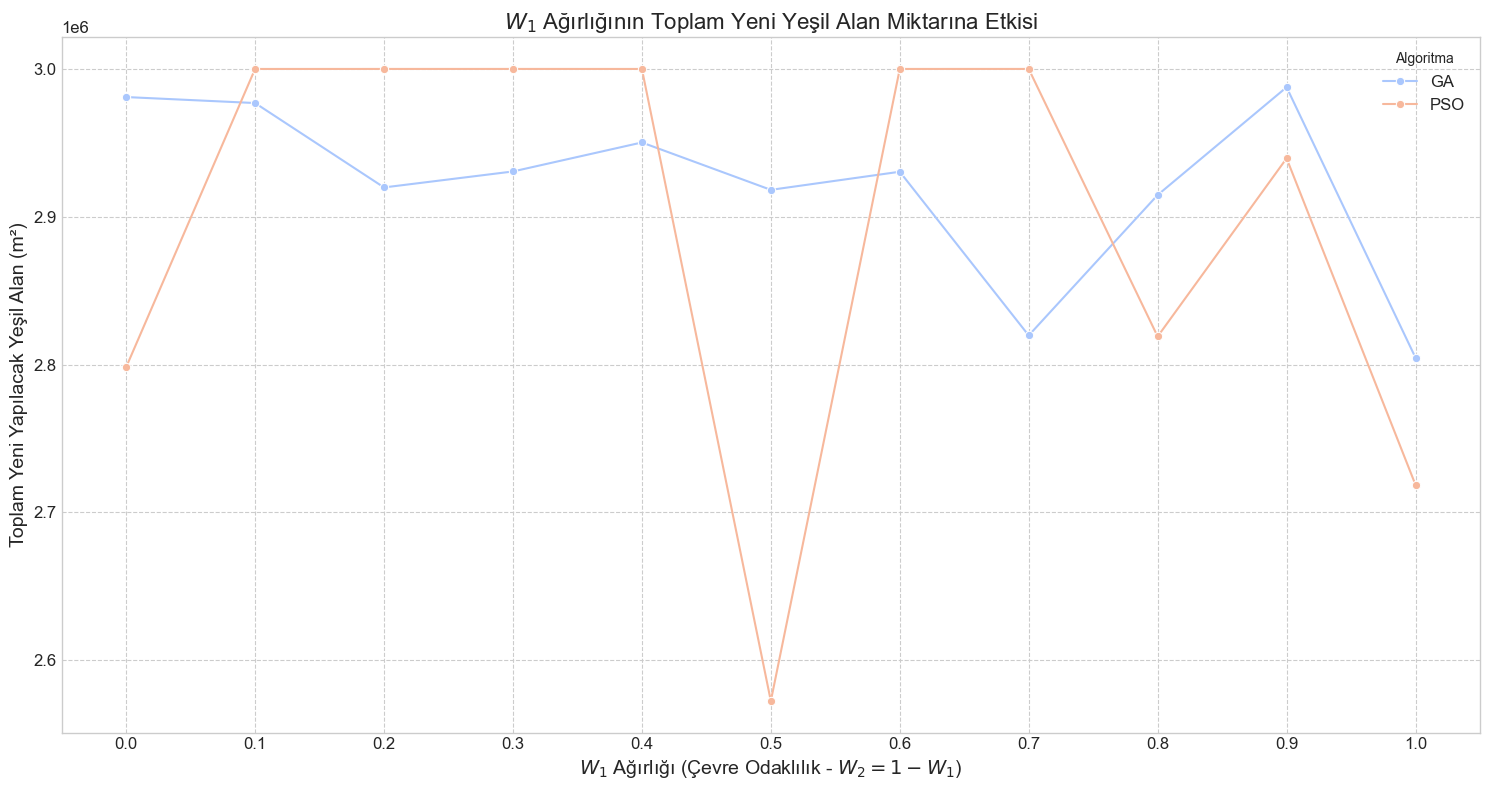

In [10]:
if df_results_final is not None and 'Yeni_Yapilacak_Yesil_Alan' in df_results_final.columns:
    df_weight_impact = df_results_final.groupby(['W1', 'Algorithm'])['Yeni_Yapilacak_Yesil_Alan'].sum().reset_index()
    # W2 = 1 - W1 varsayımıyla W1'e göre sıralayalım
    df_weight_impact = df_weight_impact.sort_values(by='W1')
    
    plt.figure(figsize=(15, 8))
    sns.lineplot(data=df_weight_impact, x='W1', y='Yeni_Yapilacak_Yesil_Alan', hue='Algorithm', marker='o', palette='coolwarm')
    plt.title('$W_1$ Ağırlığının Toplam Yeni Yeşil Alan Miktarına Etkisi')
    plt.xlabel('$W_1$ Ağırlığı (Çevre Odaklılık - $W_2 = 1 - W_1$)')
    plt.ylabel('Toplam Yeni Yapılacak Yeşil Alan (m²)')
    plt.xticks(df_weight_impact['W1'].unique()) # Ensure all W1 values are shown as ticks
    plt.legend(title='Algoritma')
    plt.grid(True, which='both', linestyle='--')
    plt.tight_layout()
    plt.show()
elif df_results_final is None:
    print("Sonuç verileri işlenemediği için bu bölüm atlanıyor.")
else:
    print("'Yeni_Yapilacak_Yesil_Alan' sütunu işlenmiş sonuçlarda bulunamadı.")

### 6.5. Yakınsama Grafikleri

Yakınsama grafikleri (her bir nesil/iterasyonda en iyi amaç fonksiyonu değerinin değişimi), algoritmaların çözüm arama davranışını anlamak için önemlidir. Bu grafikler, `main.py` betiğinin çalıştırılması sırasında elde edilen geçmiş (history) verilerinden üretilir.

**Not:** `new_optimum_yesil_alan_sonuclari_SCENARIOS.csv` dosyası bu geçmiş verilerini içermediğinden, bu grafikler doğrudan bu notebook'ta oluşturulamamaktadır. Yakınsama grafiklerini elde etmek için `main.py` içerisindeki ilgili `plt.plot(history_ga, ...)` ve `plt.plot(history_pso, ...)` satırlarının yorumunu kaldırıp betiği çalıştırmanız ve oluşan grafikleri kaydetmeniz gerekmektedir.

Aşağıda, `main.py` dosyasında bulunan (ve yorum satırı halinde olan) örnek bir yakınsama grafiği çizdirme kodu bulunmaktadır:
```python
# Örnek: GA Yakınsama Grafiği (main.py'den alınmıştır)
# history_ga = [...] # GA'nın her nesildeki en iyi Z değerlerini içeren liste
# plt.figure(figsize=(10, 6))
# plt.plot(history_ga, marker='o', linestyle='-', color='green')
# plt.title(f"GA Yakınsama")
# plt.xlabel("Nesil")
# plt.ylabel("En İyi Amaç Fonksiyonu Değeri (Z)")
# plt.grid(True)
# plt.tight_layout()
# plt.show()
```

---

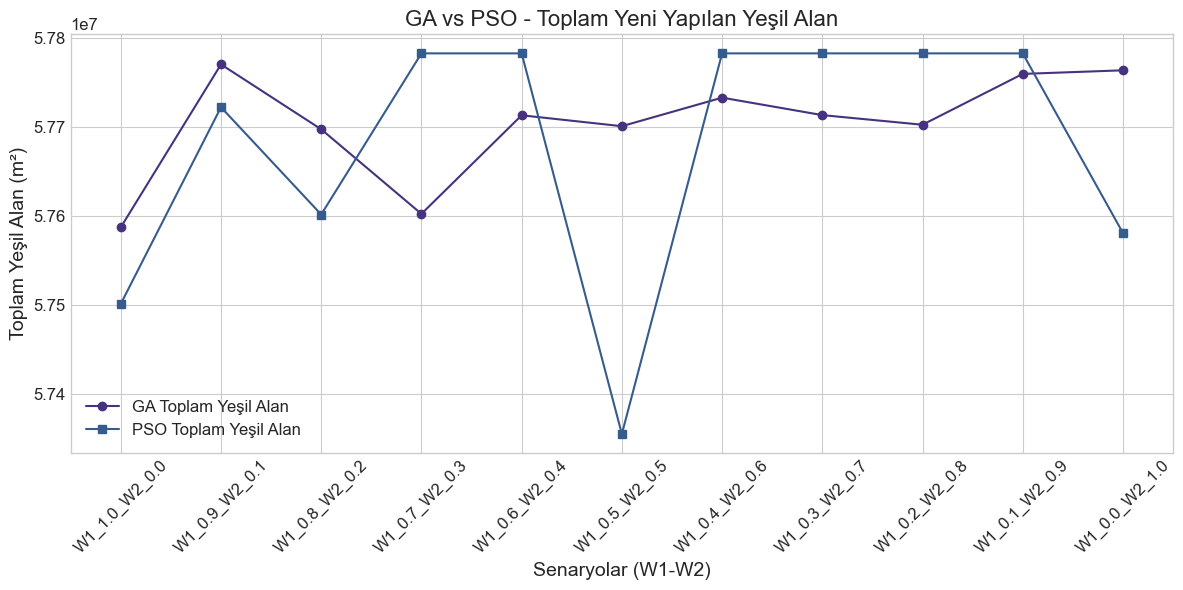

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("new_optimum_yesil_alan_sonuclari_SCENARIOS.csv")

scenarios = [
    "W1_1.0_W2_0.0", "W1_0.9_W2_0.1", "W1_0.8_W2_0.2", "W1_0.7_W2_0.3",
    "W1_0.6_W2_0.4", "W1_0.5_W2_0.5", "W1_0.4_W2_0.6", "W1_0.3_W2_0.7",
    "W1_0.2_W2_0.8", "W1_0.1_W2_0.9", "W1_0.0_W2_1.0"
]

ga_totals = [df[f"Toplam_Yesil_Alan_GA_{s}"].sum() for s in scenarios]
pso_totals = [df[f"Toplam_Yesil_Alan_PSO_{s}"].sum() for s in scenarios]

plt.figure(figsize=(12, 6))
plt.plot(scenarios, ga_totals, marker='o', label='GA Toplam Yeşil Alan')
plt.plot(scenarios, pso_totals, marker='s', label='PSO Toplam Yeşil Alan')
plt.xticks(rotation=45)
plt.xlabel("Senaryolar (W1-W2)")
plt.ylabel("Toplam Yeşil Alan (m²)")
plt.title("GA vs PSO - Toplam Yeni Yapılan Yeşil Alan")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

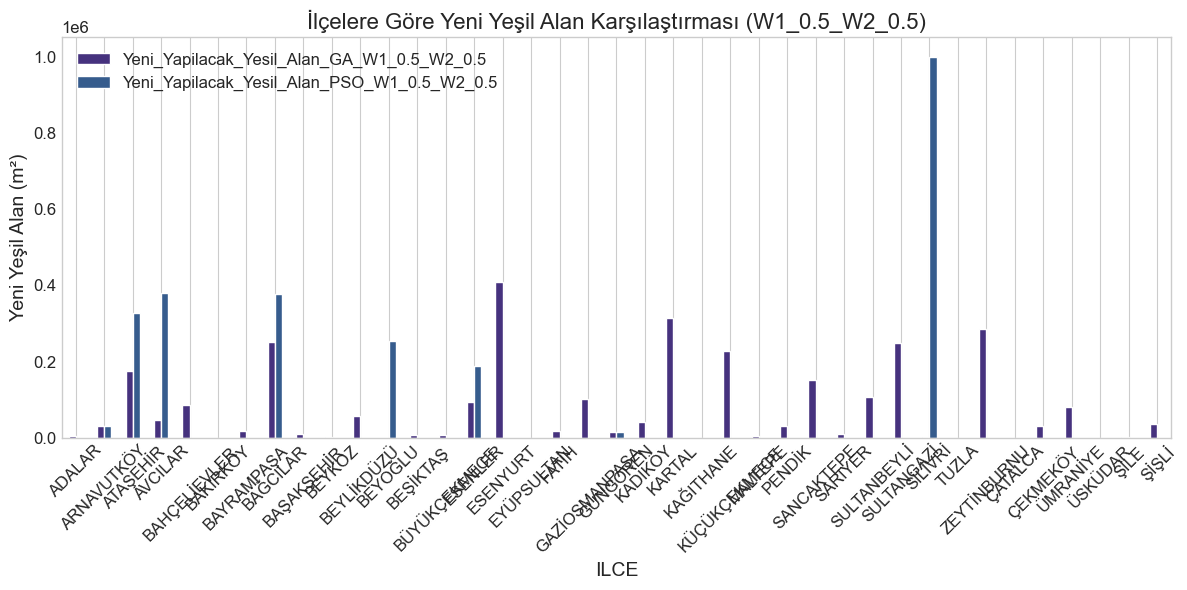

In [12]:
scenario = "W1_0.5_W2_0.5"
df_subset = df[["ILCE", f"Yeni_Yapilacak_Yesil_Alan_GA_{scenario}", f"Yeni_Yapilacak_Yesil_Alan_PSO_{scenario}"]]
df_subset.set_index("ILCE").plot(kind="bar", figsize=(12, 6))
plt.ylabel("Yeni Yeşil Alan (m²)")
plt.title(f"İlçelere Göre Yeni Yeşil Alan Karşılaştırması ({scenario})")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

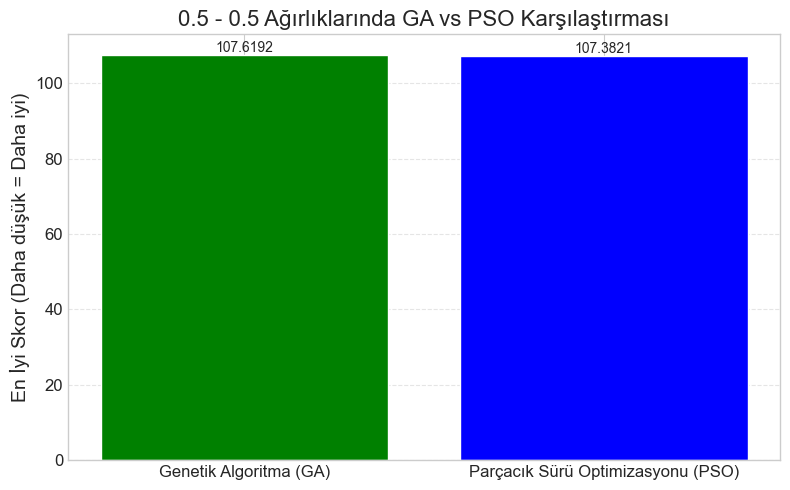

In [5]:
# CSV'den skorları oku
df_scores = pd.read_csv("../outputs/for_experiments.csv")

# 0.5-0.5 senaryosunu al
target = df_scores[(df_scores["W1"] == 0.5) & (df_scores["W2"] == 0.5)].iloc[0]

ga_score = target["Best_Score_GA"]
pso_score = target["Best_Score_PSO"]

# Görselleştirme
labels = ["Genetik Algoritma (GA)", "Parçacık Sürü Optimizasyonu (PSO)"]
scores = [ga_score, pso_score]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, scores, color=["green", "blue"])
plt.ylabel("En İyi Skor (Daha düşük = Daha iyi)")
plt.title("0.5 - 0.5 Ağırlıklarında GA vs PSO Karşılaştırması")

# Skorların üstüne yaz
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.4f}", ha="center", va="bottom")

plt.grid(axis='y', linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
